# Project: Deep Q-Learning for High-Frequency Market Making

## Context and Objectives
The objective of this project is to design an artificial intelligence agent capable of acting as a **Market Maker** on a simulated order book. 

The role of the Market Maker is to provide liquidity by simultaneously placing buy (**bid**) and sell (**ask**) orders. It profits from the difference between these two prices (the **spread**), but is exposed to two major risks:
* **Inventory risk**: Accumulating too many assets while the price is falling.
* **Adverse selection**: Being executed against by better-informed traders who anticipate price movements.

## Methodology
We use the **DQN (Deep Q-Network)** algorithm to learn an optimal quoting policy. The agent must learn to adjust its distances from the market price based on the state of the order book and its own risk.

In order to rigorously evaluate the performance and relevance of our approach, we will compare the DQN-based strategy against several benchmark algorithms:

- The **Avellaneda-Stoikov model**, a well-established analytical framework for optimal market making under inventory risk.
- A **random policy baseline**, where quotes are generated without any learned structure, serving as a lower bound for performance.

This comparative analysis will allow us to demonstrate the effectiveness of our DQN model in adapting to market dynamics, managing inventory risk, and outperforming both traditional models and alternative reinforcement learning approaches.

## Project Structure
The project is structured into several key modules:

* `env/data_lob.py`: Generates a **stochastic simulation of the Limit Order Book (LOB)**, modeling order arrivals, cancellations, and price dynamics to approximate real market conditions.

* `env/MM_env.py`: Defines a **Gymnasium-compatible trading environment** that handles the interaction between the agent and the market, including state representation, execution logic, inventory tracking, and reward computation.

* `dqn_agent.py`: Contains the **DQN agent implementation**, including the neural network architecture, experience replay buffer, and epsilon-greedy exploration strategy.

* `train_dqn.py`: Script responsible for **training the DQN agent**, orchestrating environment interactions, learning updates, and performance monitoring over episodes.

* `runs_dqn`: Directory used to **store trained DQN model weights, checkpoints, and training logs** for later evaluation or reuse.

* `eval.py`: Evaluation module designed to **compare the performance of different strategies** (DQN, Random policy, Avellaneda-Stoikov) using consistent metrics such as PnL, inventory risk, and stability.


# 0. Stochastic simulation of The Limit Order Book (LOB) and Data Analysis

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import rcParams

rcParams['figure.facecolor'] = '#0a0a0f'
rcParams['axes.facecolor']   = '#111118'
rcParams['axes.edgecolor']   = '#2a2a3a'
rcParams['text.color']       = '#e2e2ef'
rcParams['axes.labelcolor']  = '#6b7280'
rcParams['xtick.color']      = '#6b7280'
rcParams['ytick.color']      = '#6b7280'
rcParams['grid.color']       = '#2a2a3a'
rcParams['grid.linewidth']   = 0.5
rcParams['font.family']      = 'monospace'
rcParams['figure.dpi']       = 120

C_ACCENT  = '#7c6af7'
C_CYAN    = '#22d3ee'
C_ORANGE  = '#fb923c'
C_GREEN   = '#4ade80'
C_RED     = '#f87171'
C_MUTED   = '#6b7280'

## Data Generation and Statistical Validation

In this section, we generate two distinct datasets using our Limit Order Book (LOB) simulator:

- **Training Dataset**: Used to train the reinforcement learning agent.  
- **Evaluation Dataset**: Used to test the agent on new, unseen market trajectories (Out-of-Sample).

**Train/Eval Split**: We use different random seeds (`42` for training, `999` for evaluation) to ensure that the agent is evaluated on price paths it has never seen before. This is critical to verify its **generalization capabilities**.

---

## Core Mathematical Models

The LOB simulator generates realistic market data using a few key stochastic mechanisms:

### 1. Spread Dynamics (Mean-Reversion)

The bid-ask spread fluctuates but tends to return to a long-term average:

$$
s_t = s_{t-1} + \kappa (\bar{s} - s_{t-1}) + \sigma_s \epsilon_t
$$

- $s_t$ : spread at time $t$  
- $\bar{s}$ : long-term average spread  
- $\kappa$ : speed of mean-reversion  
- $\sigma_s$ : volatility of the spread  
- $\epsilon_t$ : random noise

### 2. Mid-Price Dynamics

The mid-price evolves stochastically and is affected by order book imbalance:

$$
m_t = m_{t-1} + \sigma_m \eta_t + k_{\text{imb}} \cdot \frac{q_b - q_a}{q_b + q_a}
$$

- $m_t$ : mid-price at time $t$  
- $\sigma_m$ : volatility  
- $\eta_t$ : random noise  
- $q_b, q_a$ : bid and ask queue sizes  
- $k_{\text{imb}}$ : sensitivity to imbalance 

### 3. Order Flow (Poisson Processes)

Orders arrive randomly according to **Poisson processes**:

$$
N \sim \text{Poisson}(\lambda \cdot \Delta t)
$$

- $N$ : number of events in one time step  
- $\lambda$ : average rate of events per time step 

Each time step, three types of events occur:

- $L_t$ : **Limit orders** – add liquidity to the book  
- $M_t$ : **Market orders** – consume liquidity by executing trades  
- $C_t$ : **Cancellations** – remove existing limit orders  

### 4. Queue Dynamics

Liquidity evolves as:

$$
q_t = q_{t-1} + L_t - M_t - C_t
$$

- $q_t$ : number of shares at best bid/ask  
- Builds an evolving **supply-demand balance**

### 5. State-Dependent Intensities

The arrival rates ($\lambda$) depend on the current market state:

- $ \lambda_L $ : frequency of limit orders  
- $ \lambda_M $ : frequency of market orders  
- $ \lambda_C $ : frequency of cancellations  

**Effects:**

- **Spread Effect**  
  - Large spread → fewer limit orders ($\lambda_L \downarrow$), more market orders ($\lambda_M \uparrow$)  
  - Tight spread → more limit orders ($\lambda_L \uparrow$)  

- **Depth Effect**  
  $$
  \lambda_L \propto (q_0 - q)
  $$
  - Low liquidity → more limit orders arrive  
  - High liquidity → fewer limit orders  

- **Cancellation Effect**  
  $$
  \lambda_C \propto \frac{q}{q_0}
  $$
  - More liquidity → more cancellations  

### 6. Price Formation

Bid and ask prices are set around the mid-price:

$$
\text{bid}_t = m_t - \frac{s_t}{2}, \quad
\text{ask}_t = m_t + \frac{s_t}{2}
$$

### Intuition

- $L_t$ builds the book  
- $M_t$ consumes the book  
- $C_t$ reshapes the book  
- Spread tends to revert to a mean  
- Mid-price is stochastic and influenced by imbalance  

Together, these mechanisms produce a **realistic synthetic Limit Order Book**, ideal for training and evaluating reinforcement learning agents.

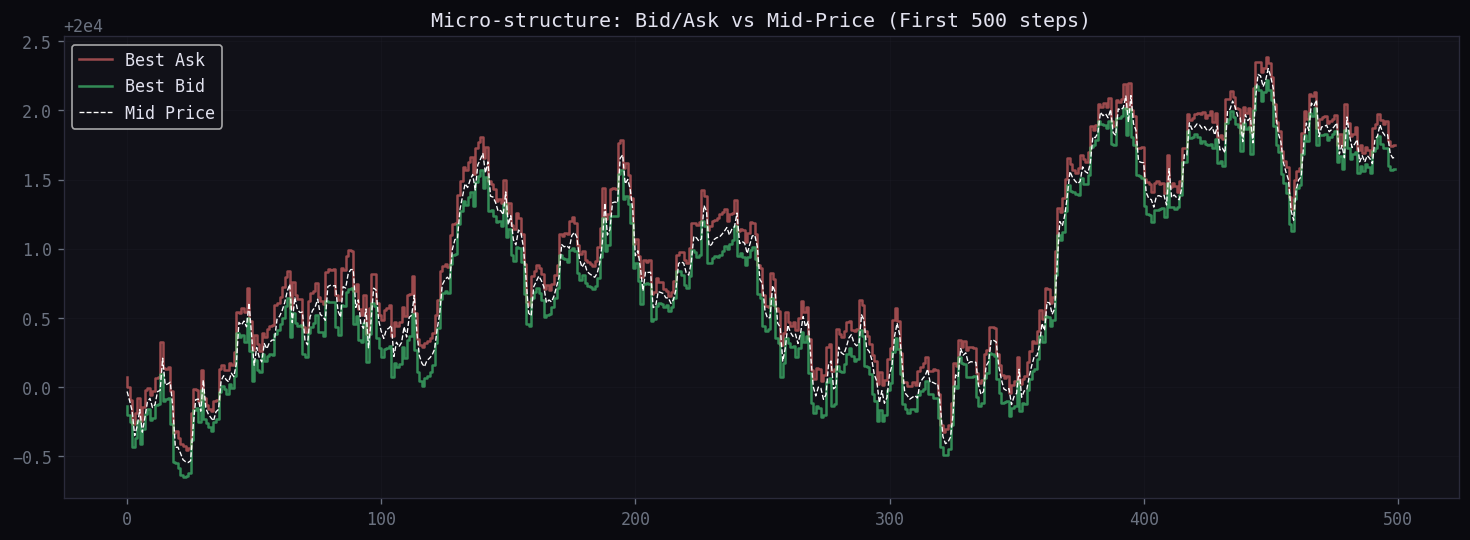

Spread moyen   : 0.2002  (cible 0.2000)
Ret σ          : 0.1237
Autocorr(1)    : 0.0015
Drift mid      : +41.1 pts sur 100,000 steps


In [16]:
from env.data_lob import LOBConfig, simulate
import matplotlib.pyplot as plt

lob_train = simulate(LOBConfig(n_steps=100_000, seed=42))
lob_eval  = simulate(LOBConfig(n_steps=100_000, seed=999))   # out-of-sample

mid    = lob_eval['mid'].values
spread = (lob_eval['ask_price_1'] - lob_eval['bid_price_1']).values
ret    = np.diff(mid)


# 1. Zoom on Price & Spread (First 500 steps)
plt.figure(figsize=(15, 5))
plt.step(range(500), lob_eval['ask_price_1'][:500], color=C_RED, alpha=0.6, label='Best Ask')
plt.step(range(500), lob_eval['bid_price_1'][:500], color=C_GREEN, alpha=0.6, label='Best Bid')
plt.plot(mid[:500], color='white', lw=0.8, ls='--', label='Mid Price')
plt.title("Micro-structure: Bid/Ask vs Mid-Price (First 500 steps)", color='#e2e2ef')
plt.legend()
plt.grid(alpha=0.2)
plt.show()


print(f"Spread moyen   : {spread.mean():.4f}  (cible 0.2000)")
print(f"Ret σ          : {ret.std():.4f}")
print(f"Autocorr(1)    : {np.corrcoef(ret[:-1], ret[1:])[0,1]:.4f}")
print(f"Drift mid      : {mid[-1] - mid[0]:+.1f} pts sur {len(mid):,} steps")

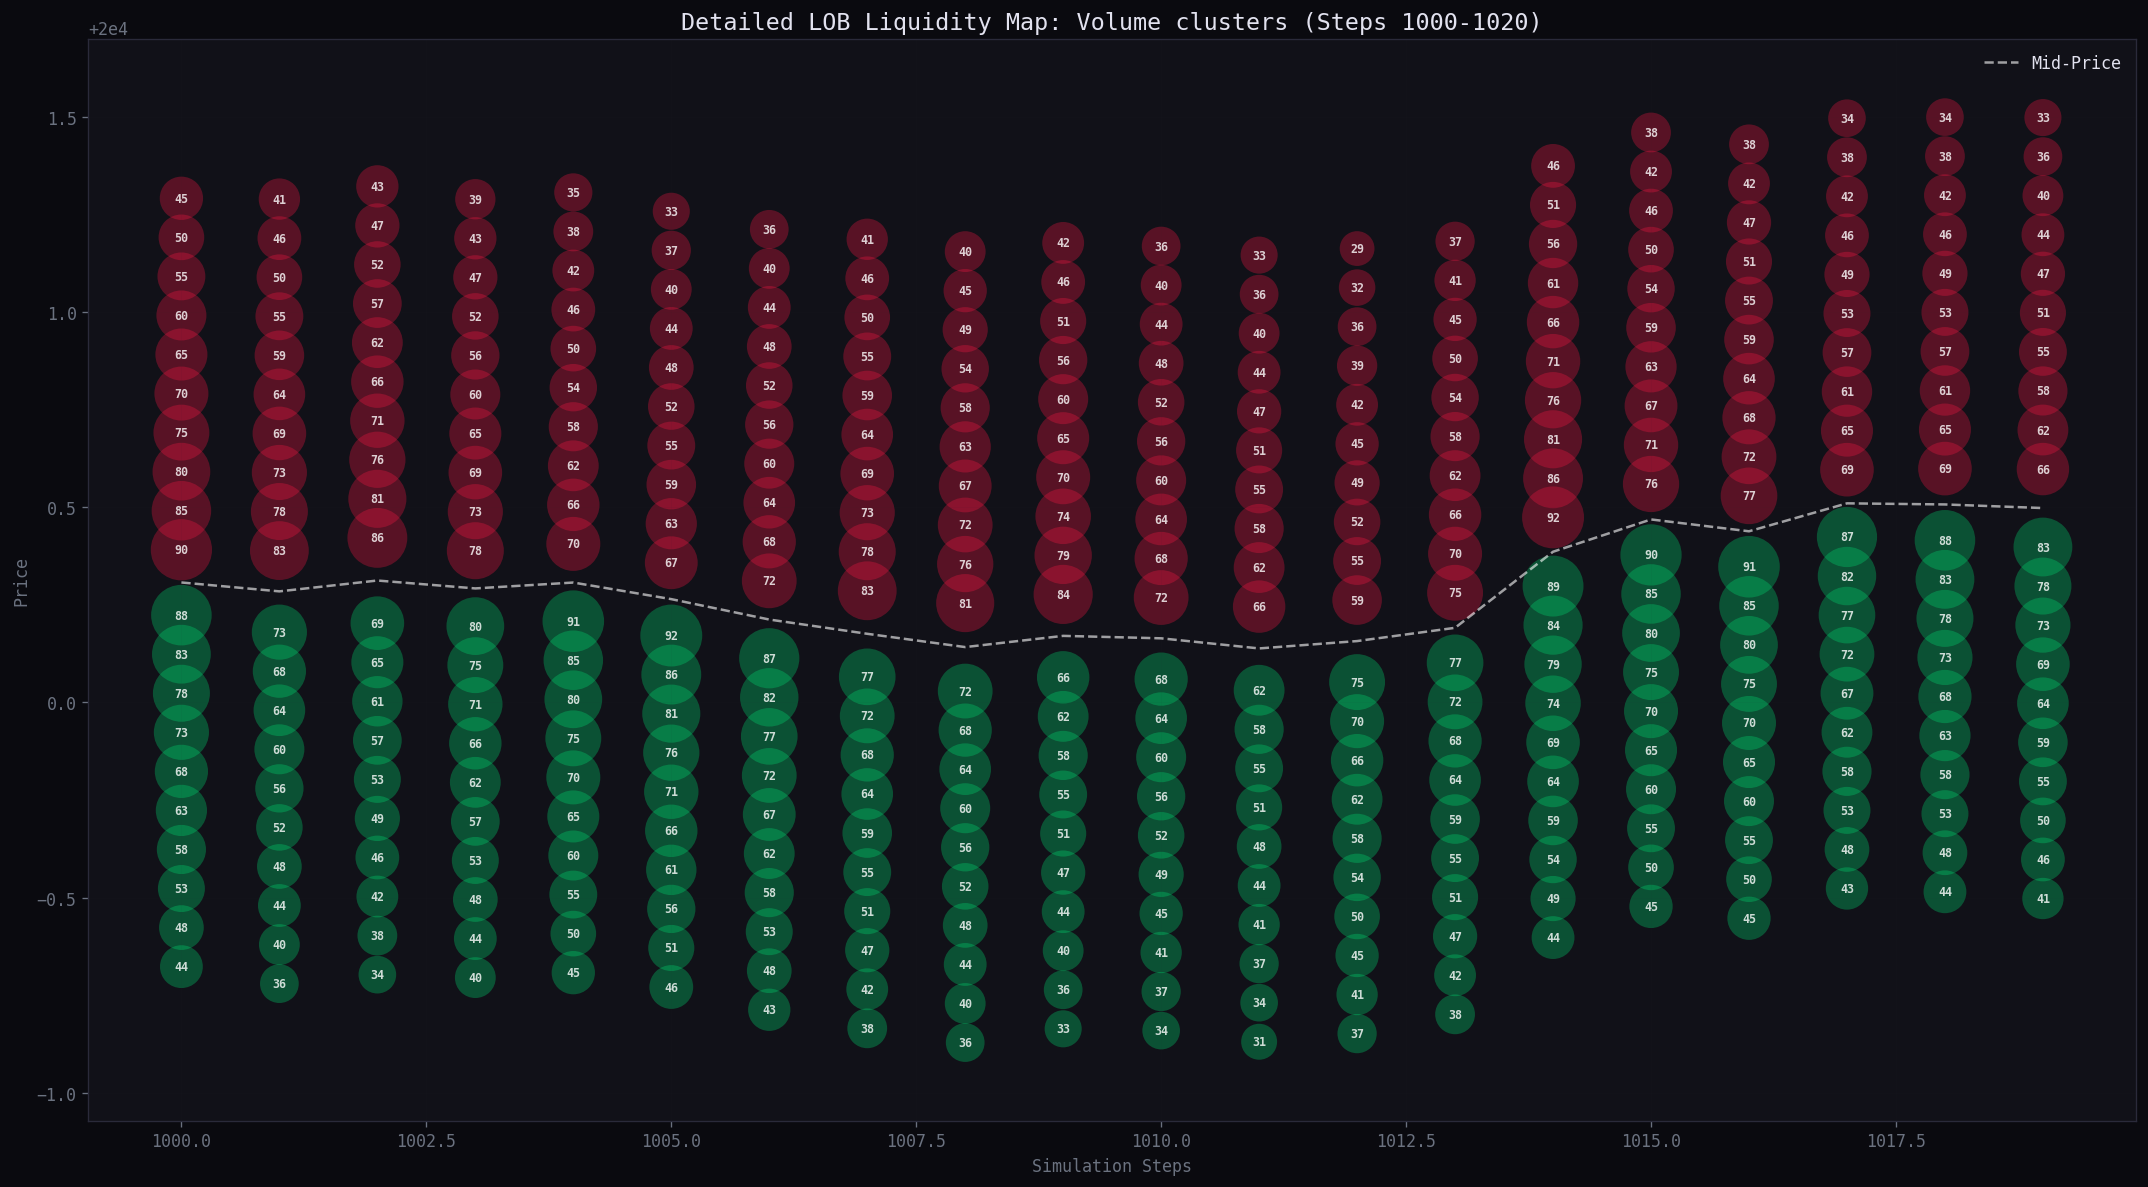

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Configuration: We keep a small window (e.g., 20-30 steps) for readability
start, end = 1000, 1020
time_steps = np.arange(start, end)

plt.figure(figsize=(18, 10))
plt.title(f"Detailed LOB Liquidity Map: Volume clusters (Steps {start}-{end})", 
          color='#e2e2ef', fontsize=14)

# 2. Plotting levels with annotations
for i in range(1, 11):  # Levels 1 to 10
    for t in time_steps:
        # --- Bids (Buyers) ---
        b_price = lob_eval[f'bid_price_{i}'].iloc[t]
        b_size  = int(lob_eval[f'bid_size_{i}'].iloc[t])
        
        plt.scatter(t, b_price, s=b_size * 15, color='#00e676', alpha=0.3, edgecolors='none')
        # Add the volume text in the center of the bubble
        plt.text(t, b_price, str(b_size), color='white', fontsize=7, 
                 ha='center', va='center', fontweight='bold', alpha=0.8)

        # --- Asks (Sellers) ---
        a_price = lob_eval[f'ask_price_{i}'].iloc[t]
        a_size  = int(lob_eval[f'ask_size_{i}'].iloc[t])
        
        plt.scatter(t, a_price, s=a_size * 15, color='#ff1744', alpha=0.3, edgecolors='none')
        # Add the volume text in the center of the bubble
        plt.text(t, a_price, str(a_size), color='white', fontsize=7, 
                 ha='center', va='center', fontweight='bold', alpha=0.8)

# 3. Mid-Price Line
plt.plot(time_steps, mid[start:end], color='white', lw=1.5, ls='--', alpha=0.6, label='Mid-Price')

# 4. Final Styling
plt.ylabel("Price", color='#6b7280')
plt.xlabel("Simulation Steps", color='#6b7280')
plt.grid(True, alpha=0.05)
plt.legend(loc='upper right', facecolor='#111118', edgecolor='none')

# Focus Y-axis on the active range
y_min = lob_eval['bid_price_10'][start:end].min() - 0.2
y_max = lob_eval['ask_price_10'][start:end].max() + 0.2
plt.ylim(y_min, y_max)

plt.tight_layout()
plt.show()

### Annotated Liquidity Map: Deep Volume Analysis

This chart offers a microscopic view of the market's microstructure. By displaying the **exact volume** at each price level, we can perform a "Tape Reading" analysis of the simulation.

#### Key Insights:

1.  **Liquidity Density**: Large circles containing high numbers (e.g., > 80 units) represent strong support or resistance zones. The DQN agent must learn that these levels are harder to "break" through.
2.  **Order Matching Visualization**: When a high-volume bubble at Level 1 (closest to mid) suddenly disappears or shrinks in the next step, it visually confirms a **Trade Execution**.
3.  **The "Spoofing" Effect**: In this simulation, you can observe how liquidity shifts. If volume moves from Level 3 to Level 1, it indicates an increasing urgency from market participants, often preceding a price move.
4.  **Spread Dynamics**: The numerical gap between the highest green number and lowest red number is the cost of liquidity. If these numbers are small, the market is "thin" and prone to slippage.



**Conclusion for the Agent**:
By visualizing these numbers, we confirm that the environment provides rich, structured information. While our current agent primarily sees Level 1, these "Liquidity Walls" at deeper levels are predictive signals that could be used to enhance the agent's performance in future iterations.

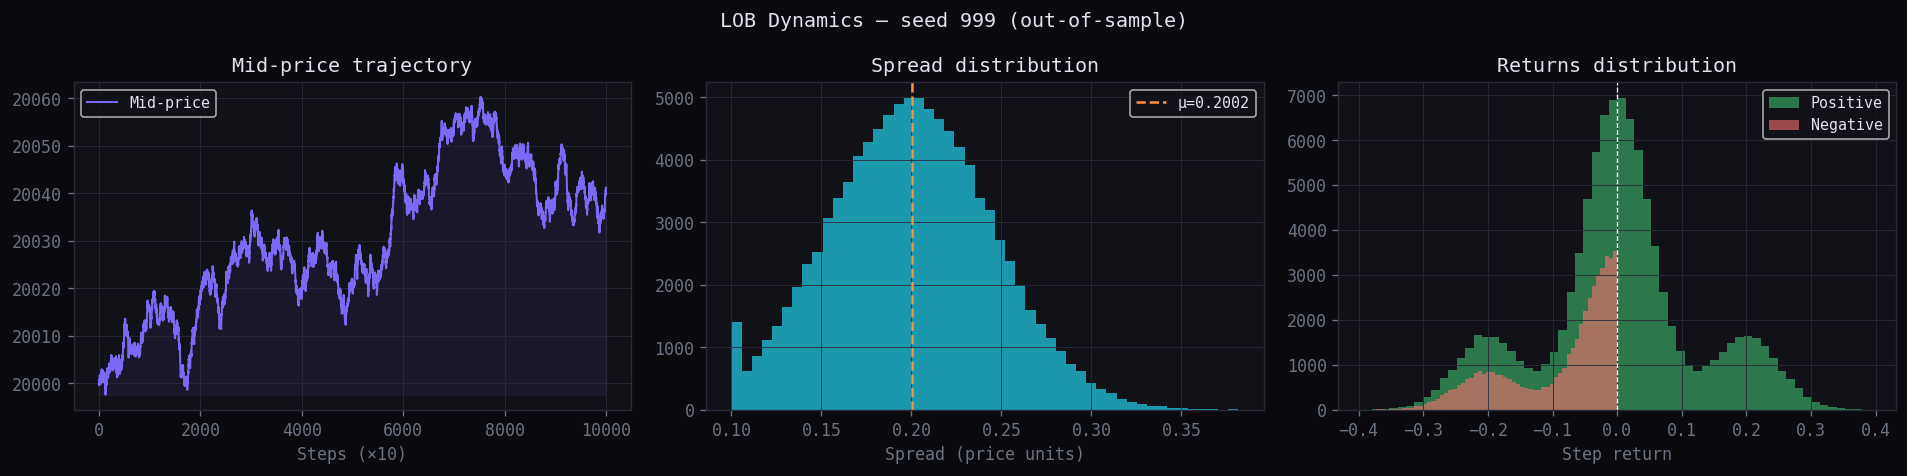

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('LOB Dynamics — seed 999 (out-of-sample)', color='#e2e2ef', fontsize=12)

# Mid-price
ax = axes[0]
ax.plot(mid[::10], color=C_ACCENT, lw=1.2, label='Mid-price')
ax.fill_between(range(len(mid[::10])), mid[::10], mid[::10].min(), alpha=0.08, color=C_ACCENT)
ax.set_title('Mid-price trajectory', color='#e2e2ef')
ax.set_xlabel('Steps (×10)')
ax.grid(True)
ax.legend(fontsize=9)

# Spread distribution
ax = axes[1]
ax.hist(spread, bins=50, color=C_CYAN, alpha=0.7, edgecolor='none')
ax.axvline(spread.mean(), color=C_ORANGE, lw=1.5, ls='--', label=f'μ={spread.mean():.4f}')
ax.set_title('Spread distribution', color='#e2e2ef')
ax.set_xlabel('Spread (price units)')
ax.grid(True)
ax.legend(fontsize=9)

# Returns distribution
ax = axes[2]
ax.hist(ret, bins=60, color=C_GREEN, alpha=0.5, edgecolor='none', label='Positive')
neg_ret = ret[ret < 0]
ax.hist(neg_ret, bins=60, color=C_RED, alpha=0.6, edgecolor='none', label='Negative')
ax.axvline(0, color='white', lw=0.8, ls='--')
ax.set_title('Returns distribution', color='#e2e2ef')
ax.set_xlabel('Step return')
ax.grid(True)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### Exploratory Data Analysis: LOB Dynamics (Out-of-Sample)

Before evaluating the agent's performance, it is crucial to analyze the statistical properties of the unseen evaluation data (Seed 999). This ensures the "market" the agent is entering is representative of realistic trading conditions.

* **Mid-price Trajectory**: The first plot tracks the evolution of the asset's price over time. We observe the Geometric Brownian Motion (GBM) combined with mean-reverting dynamics, which tests the agent's ability to remain profitable across different market regimes (uptrends, downtrends, and sideways markets).

* **Spread Distribution**: The second plot shows the histogram of the bid-ask spread. A concentrated distribution near the mean ($\mu$) indicates a stable liquidity environment, while the tails represent periods of high volatility where the agent must decide whether to widen its quotes to manage risk.

* **Returns Distribution**: The third plot displays the step-by-step returns. The symmetry and the shape of the tails are key; in high-frequency trading, "fat tails" (kurtosis) often indicate sudden price jumps, which are the primary source of **Adverse Selection** risk for our DQN agent.



**Note**: Analyzing these dynamics helps in understanding if the agent's learned policy is robust enough to handle the realized volatility and price shocks present in the out-of-sample dataset.

# 1. Avellaneda-Stoikov VS Random

### Baseline Strategy Comparison: Analytics vs. Randomness

Before evaluating our trained DQN agent, we run a benchmark simulation to establish the performance of two fundamental strategies:

* **Avellaneda-Stoikov Policy**: This is our "gold standard" analytical baseline. It uses a closed-form solution to determine the indifference price based on the agent's current inventory and the remaining time in the episode. It represents how a sophisticated, risk-averse human trader might price liquidity.
* **Random Policy**: This serves as our "performance floor". By selecting bid and ask offsets uniformly at random, it highlights the difficulty of the task and demonstrates the baseline losses incurred without a strategic approach.

#### Execution Logic
The loop iterates through these policies and interacts with the **MarketMakingEnv** using the out-of-sample `lob_eval` data. We track three critical metrics per step:
1.  **Cumulative Rewards**: The risk-adjusted profit (PnL minus inventory and holding penalties).
2.  **Inventory Levels**: Monitoring how much directional risk each policy accumulates over time.
3.  **Raw PnL**: The pure trading profit before any risk-adjusted penalties are applied.


In [19]:
from dqn_agent import DQNAgent
from env.MM_env import EnvConfig, MarketMakingEnv
from eval import AvellanedaStoikovPolicy, RandomPolicy, compare_policies, print_report

import os
import glob
from train_dqn import train_dqn
from dqn_agent import DQNAgent
from env.MM_env import EnvConfig

# 1. Configuration
env_cfg = EnvConfig(inventory_penalty=0.5, holding_cost=0.01)

policies = {
    'Avellaneda-Stoikov': AvellanedaStoikovPolicy(
        gamma=env_cfg.inventory_penalty, sigma=0.124, kappa=1.5,
        T=2000, n_levels=5, min_offset=1, max_offset=5
    ),
    'Random': RandomPolicy(n_actions=25, seed=0),
}

ep_data = {}
for name, policy in policies.items():
    env = MarketMakingEnv(lob_eval, env_cfg)
    obs, _ = env.reset(seed=42)
    rewards, inv, raw_pnl, cum_r = [], [], [], 0.0
    for _ in range(2000):
        action, _ = policy.predict(obs, deterministic=True)
        obs, r, term, trunc, info = env.step(action)
        cum_r += r
        rewards.append(cum_r)
        inv.append(info['inventory'])
        raw_pnl.append(info['step_pnl'])
        if term or trunc:
            break
    ep_data[name] = {
        'rewards': np.array(rewards),
        'inv':     np.array(inv),
        'raw_pnl': np.cumsum(raw_pnl),
    }
    print(f"{name:25s}  reward={cum_r:+.1f}  raw_pnl={sum(raw_pnl):+.1f}  "
          f"pen={sum(raw_pnl)-cum_r:+.1f}  |inv|_mean={np.abs(inv).mean():.1f}")

Avellaneda-Stoikov         reward=-2557.9  raw_pnl=+302.2  pen=+2860.1  |inv|_mean=1.0
Random                     reward=-2379455.3  raw_pnl=+134.5  pen=+2379589.8  |inv|_mean=43.3


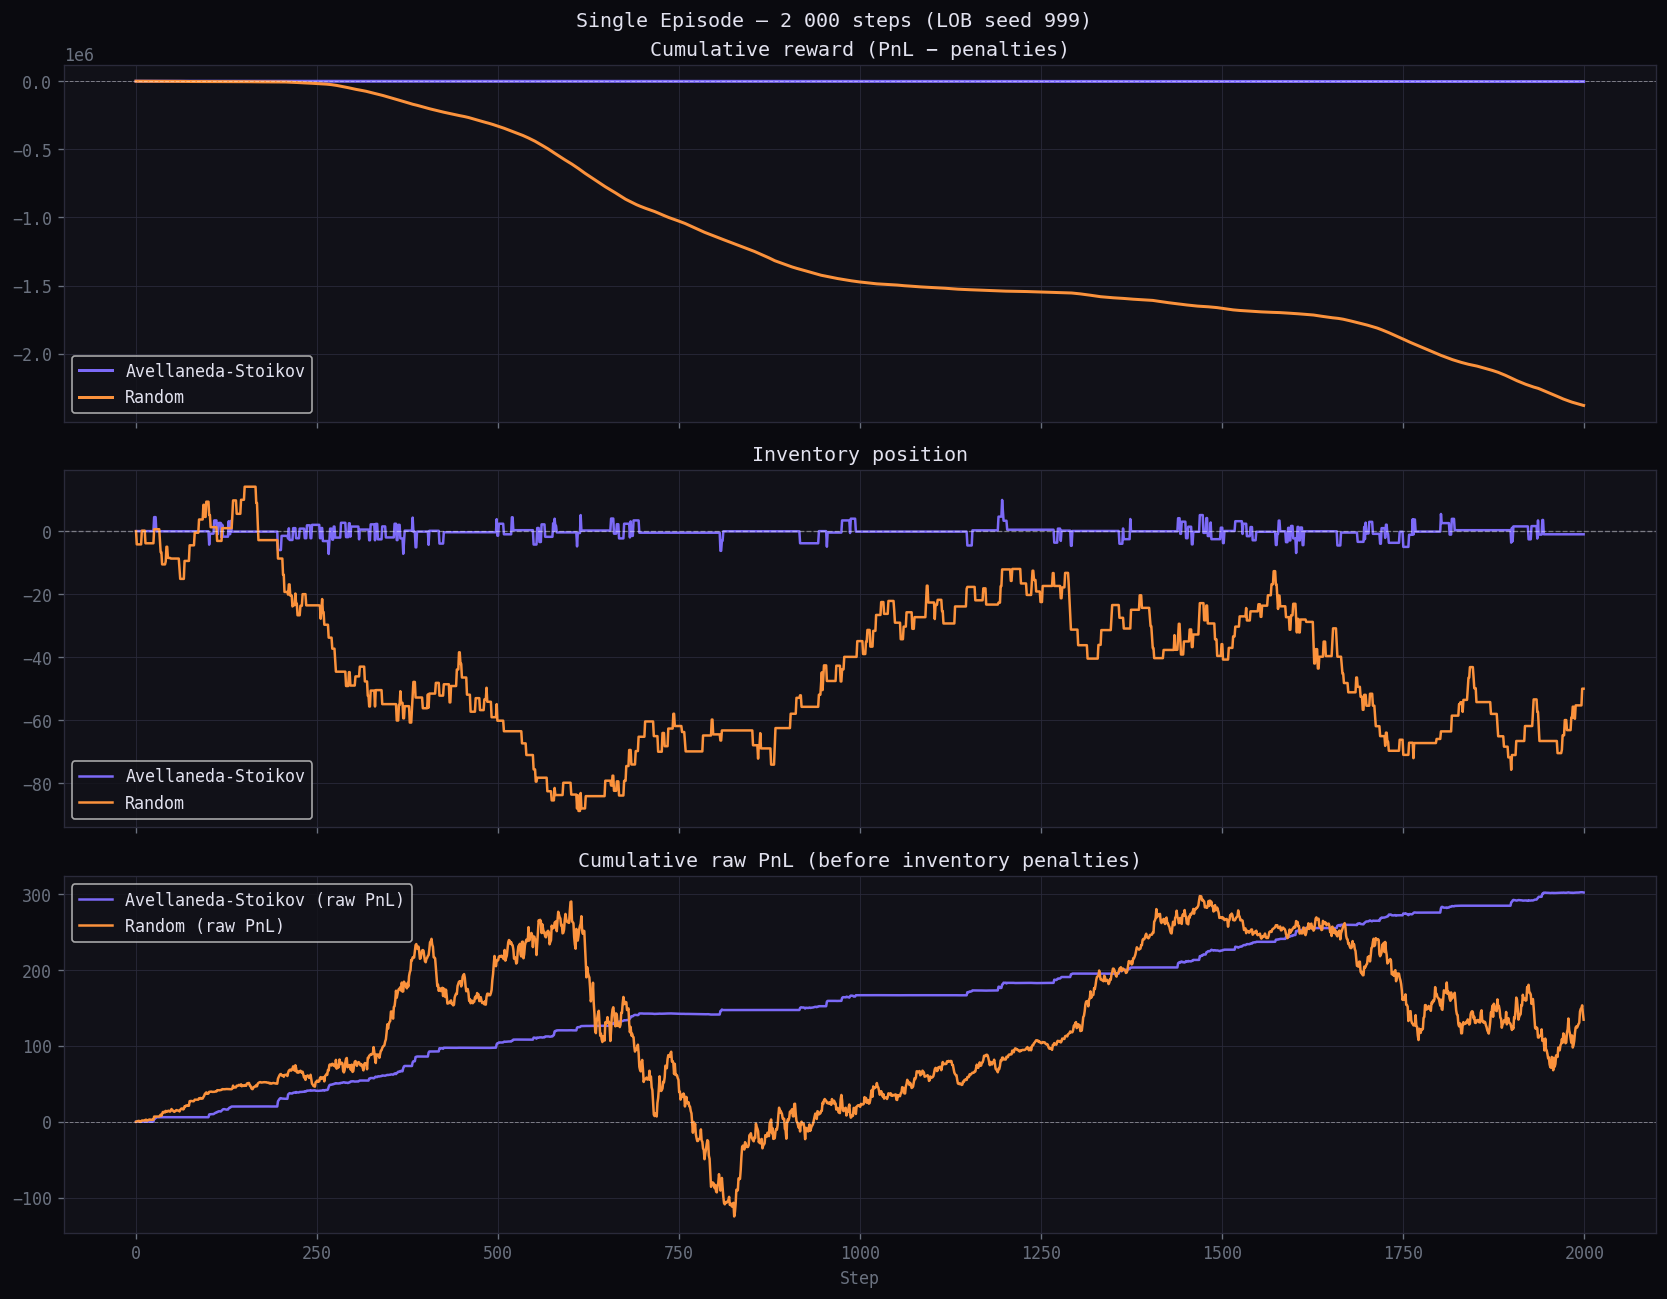

In [20]:
colors = {'Avellaneda-Stoikov': C_ACCENT, 'Random': C_ORANGE}
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle('Single Episode — 2 000 steps (LOB seed 999)', color='#e2e2ef', fontsize=12)

# Reward cumulé
ax = axes[0]
for name, d in ep_data.items():
    ax.plot(d['rewards'], color=colors[name], lw=1.8, label=name)
ax.axhline(0, color='white', lw=0.6, ls='--', alpha=0.4)
ax.set_title('Cumulative reward (PnL − penalties)', color='#e2e2ef')
ax.legend(fontsize=10)
ax.grid(True)

# Inventaire
ax = axes[1]
for name, d in ep_data.items():
    ax.plot(d['inv'], color=colors[name], lw=1.5, label=name)
ax.axhline(0, color='white', lw=0.8, ls='--', alpha=0.4)
ax.set_title('Inventory position', color='#e2e2ef')
ax.legend(fontsize=10)
ax.grid(True)

# PnL brut
ax = axes[2]
for name, d in ep_data.items():
    ax.plot(d['raw_pnl'], color=colors[name], lw=1.5, label=f'{name} (raw PnL)')
ax.axhline(0, color='white', lw=0.6, ls='--', alpha=0.4)
ax.set_title('Cumulative raw PnL (before inventory penalties)', color='#e2e2ef')
ax.set_xlabel('Step')
ax.legend(fontsize=10)
ax.grid(True)

plt.tight_layout()
plt.show()

### Time-Series Analysis: Strategy Behavior over a Single Episode

This visualization provides a granular view of how the benchmark strategies interact with the market over a continuous 2,000-step horizon. By aligning the Reward, Inventory, and Raw PnL, we can diagnose the specific strengths and weaknesses of each approach.

* **Cumulative Reward (Risk-Adjusted Performance)**: 
    * The **Avellaneda-Stoikov** strategy shows a much smoother, controlled decay compared to the **Random** policy. 
    * The massive downward slope of the Random policy illustrates how quickly unmanaged inventory costs can overwhelm a trading account.
* **Inventory Position (Risk Exposure)**: 
    * This is the "engine room" of the simulation. **Avellaneda-Stoikov** displays a mean-reverting behavior, constantly pulling the position back toward zero. 
    * In contrast, the **Random** policy exhibits a "random walk" in inventory, often drifting far from neutrality (reaching +/- 60 units), which exposes the agent to significant price shocks.
* **Cumulative Raw PnL (Gross Trading Profit)**: 
    * Both strategies manage to generate positive gross profit at various points, confirming that the Market Making environment provides enough spread-capture opportunities. 
    * However, the **Avellaneda-Stoikov** strategy captures this profit more consistently and with lower variance, as it strategically places quotes where they are most likely to be filled profitably given the current inventory skew.



#### Strategic Insights
The correlation between the **Inventory** spikes and the **Reward** drops is the most important takeaway for our DQN agent's training. Whenever the inventory deviates significantly from zero, the penalty terms (calculated in `MM_env.py`) accelerate the loss in Reward. To outperform these baselines, the DQN agent must learn a "neutralization" reflex: tightening the spread on one side to encourage trades that reduce the current inventory.

# 2. DQN VS Avellaneda-Stoikov VS Random

### 1. Goal of the Agent

The agent’s goal is to **maximize cumulative profit** while managing inventory and risk:

- Place buy/sell quotes at optimal distances from the mid-price.  
- Adapt actions based on market conditions (spread, liquidity, imbalance).  
- Learn a policy that balances **risk vs reward**.

### 2. Observations and States

At each time step, the agent observes the **market state**:

- Mid-price of the asset ($m_t$)  
- Bid-ask spread ($s_t$)  
- Queue sizes at each level ($q_b, q_a$)  
- Agent’s own inventory or positions  

This vector is called the **state** $s_t$.

### 3. Actions

The agent chooses among a discrete set of actions:

- Adjust bid/ask quotes (place orders at certain price levels)  
- Cancel existing orders  
- Decisions are **discrete**, and each action is associated with a potential reward.

### 4. Rewards

- Reward reflects **profit and risk**: e.g., P&L, inventory penalties.  
- The agent learns to **maximize long-term rewards**, not just immediate gains.

### 5. Q-Network

The agent uses a **neural network** to approximate the **action-value function** $Q(s, a)$:

- Input: state vector \( s_t \)  
- Hidden layers: fully connected layers with ReLU activation (default: `[256, 256]`)  
- Output: predicted Q-values for each possible action  

**Intuition:** $Q(s, a)$ estimates the **expected cumulative reward** for taking action $a$ in state $s$.

### 6. Epsilon-Greedy Exploration

To balance exploration vs exploitation:

- With probability $\epsilon$, select a **random action** (exploration)  
- With probability $1-\epsilon$, select the **best action according to Q-network** (exploitation)  
- $\epsilon$ decays exponentially from $\epsilon_{\text{start}}$ to $\epsilon_{\text{end}}$ over time:

$$
\epsilon_t = \epsilon_{\text{end}} + (\epsilon_{\text{start}} - \epsilon_{\text{end}}) \cdot e^{-t / \epsilon_{\text{decay}}}
$$

- Ensures the agent **explores early** and **exploits learned policy later**.

### 7. Replay Buffer

- Stores past experiences `(s_t, a_t, r_t, s_{t+1}, done)`  
- Sampling **random batches** breaks correlation between consecutive steps  
- Improves **stability and convergence** of training


### 8. Target Network

- A **copy of the Q-network** used to compute stable target values:

$$
Q_{\text{target}}(s, a) = r + \gamma Q_{\text{target}}(s', \arg\max_a Q(s', a))
$$

- Updated periodically (`target_update` steps)  
- Reduces instability caused by moving targets in Q-learning

### 9. Double DQN

- **Separates action selection and evaluation**:  
1. The Q-network chooses the best next action: 
   $$
   a^* = \arg\max_a Q(s', a)
   $$
2. The target network evaluates this action:
   $$
   Q_{\text{target}}(s', a^*)
   $$
- Reduces **overestimation of Q-values**, leading to more stable learning

### 10. Learning Step

1. Sample a batch of transitions from the **replay buffer**  
2. Compute **current Q-values** for actions taken  
3. Compute **target Q-values** using **Double DQN formula**  
4. Compute **loss** (Smooth L1 / Huber) between current and target Q-values  
5. Backpropagate gradients and update **Q-network weights**  
6. Clip gradients to prevent exploding gradients  
7. Update **target network** periodically


### 11. Intuition and Takeaways

- **States** describe the market and agent’s position  
- **Actions** manipulate liquidity in the LOB  
- **Rewards** guide learning towards profitable and safe strategies  
- **Q-network + Double DQN + Target network** allow stable and efficient learning  
- **Replay buffer** ensures diverse training experiences  
- **Epsilon decay** balances exploration and exploitation  

Together, these components allow the agent to **learn an optimal quoting policy**, adapting dynamically to market conditions and maximizing expected cumulative reward.


In [21]:
import os
import glob
from train_dqn import train_dqn
from dqn_agent import DQNAgent
from env.MM_env import EnvConfig, MarketMakingEnv
from eval import AvellanedaStoikovPolicy, RandomPolicy, compare_policies, print_report

# 1. Configuration
env_cfg = EnvConfig(inventory_penalty=0.5, holding_cost=0.01)
SAVE_DIR = 'runs_dqn'

# 2. Vérification de l'existence d'un entraînement précédent
existing_trainings = glob.glob(os.path.join(SAVE_DIR, 'dqn_*'))

if existing_trainings:
    # On récupère le dossier le plus récent
    model_dir = max(existing_trainings, key=os.path.getctime)
    model_path = os.path.join(model_dir, 'final_model.pt') 
    
    print(f"Modèle trouvé dans {model_dir}. Chargement en cours...")
    
    # Initialisation de l'agent et chargement des poids
    agent_dqn = DQNAgent(obs_dim=7, n_actions=25)
    agent_dqn.load(model_path)
    logs = None # Les logs ne sont pas récupérables facilement sans l'objet de retour
    print("Agent chargé avec succès. Prêt pour l'évaluation.")
else:
    print("Aucun entraînement trouvé. Lancement du training...")
    # Lancement de l'entraînement car rien n'existe
    agent_dqn, model_dir, logs = train_dqn(total_steps=100_000, env_cfg=env_cfg)
    print(f"Entraînement terminé. Modèle sauvegardé dans : {model_dir}")


dqn_model = DQNAgent(obs_dim=7, n_actions=25)
model_path = 'runs_dqn/dqn_20260407_155849/final_model.pt'
dqn_model.load(model_path)
print(f"✓ Agent DQN chargé depuis {model_path}")

Modèle trouvé dans runs_dqn/dqn_20260407_155849. Chargement en cours...
Agent chargé avec succès. Prêt pour l'évaluation.
✓ Agent DQN chargé depuis runs_dqn/dqn_20260407_155849/final_model.pt


# eval.py — Évaluation des stratégies de market-making

Ce module sert à **tester et comparer des stratégies de market-making** sur un carnet d’ordres simulé (LOB).

## Politiques disponibles

- **Avellaneda-Stoikov (A&S 2008)** : stratégie analytique optimale pour fixer les prix d’achat/vente selon le risque et l’inventaire.
- **RandomPolicy** : actions uniformément aléatoires, sert de référence minimale.
- **DQN agent** : 

## Fonctionnalités principales

- `evaluate_policy(policy, lob_df, env_cfg, n_episodes)`  
  Exécute la politique sur plusieurs épisodes et retourne un résumé `EvalResult` avec :
  - PnL moyen, min, max, écart-type
  - Ratio de Sharpe / Sortino
  - Taux de remplissage, nombre de trades
  - Inventaire moyen et final
  - Sélection adverse (adverse selection)
  - Distribution des actions et PnL par regime de volatilité


In [22]:
import os
import glob
import pandas as pd
from env.data_lob import LOBConfig, simulate
from env.MM_env import EnvConfig
from dqn_agent import DQNAgent
from eval import evaluate_policy, AvellanedaStoikovPolicy, RandomPolicy, print_report

def run_final_comparison():
    print(" Simulation du carnet d'ordres d'évaluation (Seed 999)...")
    lob_eval = simulate(LOBConfig(n_steps=100_000, seed=999))
    
    env_cfg = EnvConfig(inventory_penalty=0.5, holding_cost=0.01, episode_steps=2000)

    dqn_model = DQNAgent(obs_dim=7, n_actions=25)
    try:
        latest_dqn_dir = max(glob.glob('runs_dqn/dqn_*'), key=os.path.getctime)
        model_path = os.path.join(latest_dqn_dir, 'final_model.pt')
        dqn_model.load(model_path)
        print(f"Agent DQN chargé depuis : {model_path}")
    except Exception as e:
        print(f"Erreur lors du chargement du DQN : {e}")
        return

    # 3. Initialisation du dictionnaire de résultats
    results = {}
    n_episodes = 30
    seed = 42

    # --- Évaluation : Random ---
    print("Évaluation de la politique Random...")
    results["random"] = evaluate_policy(
        RandomPolicy(n_actions=25, seed=seed),
        lob_eval, env_cfg, 
        n_episodes=n_episodes, 
        policy_name="Random", 
        seed=seed, 
        deterministic=False
    )

    # --- Évaluation : Avellaneda-Stoikov ---
    print("Évaluation de la politique Avellaneda-Stoikov...")
    results["as"] = evaluate_policy(
        AvellanedaStoikovPolicy(
            gamma=env_cfg.inventory_penalty,
            sigma=0.124, 
            kappa=1.5, 
            T=env_cfg.episode_steps
        ),
        lob_eval, env_cfg, 
        n_episodes=n_episodes, 
        policy_name="Avellaneda-Stoikov", 
        seed=seed
    )

    # --- Évaluation : DQN ---
    print("Évaluation de l'agent DQN...")
    results["dqn"] = evaluate_policy(
        dqn_model,
        lob_eval, env_cfg, 
        n_episodes=n_episodes, 
        policy_name="DQN (Trained)", 
        seed=seed
    )

    # 4. Affichage du rapport final formaté
    print_report(results)

if __name__ == "__main__":
    run_final_comparison()

 Simulation du carnet d'ordres d'évaluation (Seed 999)...
Agent DQN chargé depuis : runs_dqn/dqn_20260407_155849/final_model.pt
Évaluation de la politique Random...
Évaluation de la politique Avellaneda-Stoikov...
Évaluation de l'agent DQN...

  EVALUATION REPORT
                                    RandomAvellaneda-StoikovDQN (Trained)
──────────────────────────────────────────────────────────────────────────────────
  PnL
    mean (per episode)            530.4138    391.1969    444.8114
    std                           235.2978     45.5760     41.4937
    min                            85.4570    288.2449    365.8161
    max                          1051.2495    498.1669    536.8726
──────────────────────────────────────────────────────────────────────────────────
  Risk-adjusted
    Sharpe                          0.0004      0.5121      0.0795
    Sortino                         0.0004      0.5121      0.0795
────────────────────────────────────────────────────────────────────────

In [23]:
from env.data_lob import LOBConfig, simulate
import numpy as np

lob_eval = simulate(LOBConfig(n_steps=50_000, seed=999))
env_cfg_eval = EnvConfig(episode_steps=2000)


policies = {
    'Avellaneda-Stoikov': AvellanedaStoikovPolicy(
        gamma=env_cfg_eval.inventory_penalty, 
        sigma=0.124, 
        kappa=1.5
    ),
    'Random': RandomPolicy(n_actions=25),
    'DQN (Trained)': dqn_model
}

ep_data = {}
for name, policy in policies.items():
    env = MarketMakingEnv(lob_eval, env_cfg)
    obs, _ = env.reset(seed=42)
    rewards, inv, raw_pnl, cum_r = [], [], [], 0.0
    for _ in range(2000):
        action, _ = policy.predict(obs, deterministic=True)
        obs, r, term, trunc, info = env.step(action)
        cum_r += r
        rewards.append(cum_r)
        inv.append(info['inventory'])
        raw_pnl.append(info['step_pnl'])
        if term or trunc:
            break
    ep_data[name] = {
        'rewards': np.array(rewards),
        'inv':     np.array(inv),
        'raw_pnl': np.cumsum(raw_pnl),
    }
    print(f"{name:25s}  reward={cum_r:+.1f}  raw_pnl={sum(raw_pnl):+.1f}  "
          f"pen={sum(raw_pnl)-cum_r:+.1f}  |inv|_mean={np.abs(inv).mean():.1f}")

Avellaneda-Stoikov         reward=-37975.8  raw_pnl=+228.0  pen=+38203.9  |inv|_mean=4.2
Random                     reward=-749864.0  raw_pnl=+276.0  pen=+750140.0  |inv|_mean=21.6
DQN (Trained)              reward=-11484.8  raw_pnl=+414.0  pen=+11898.8  |inv|_mean=2.5


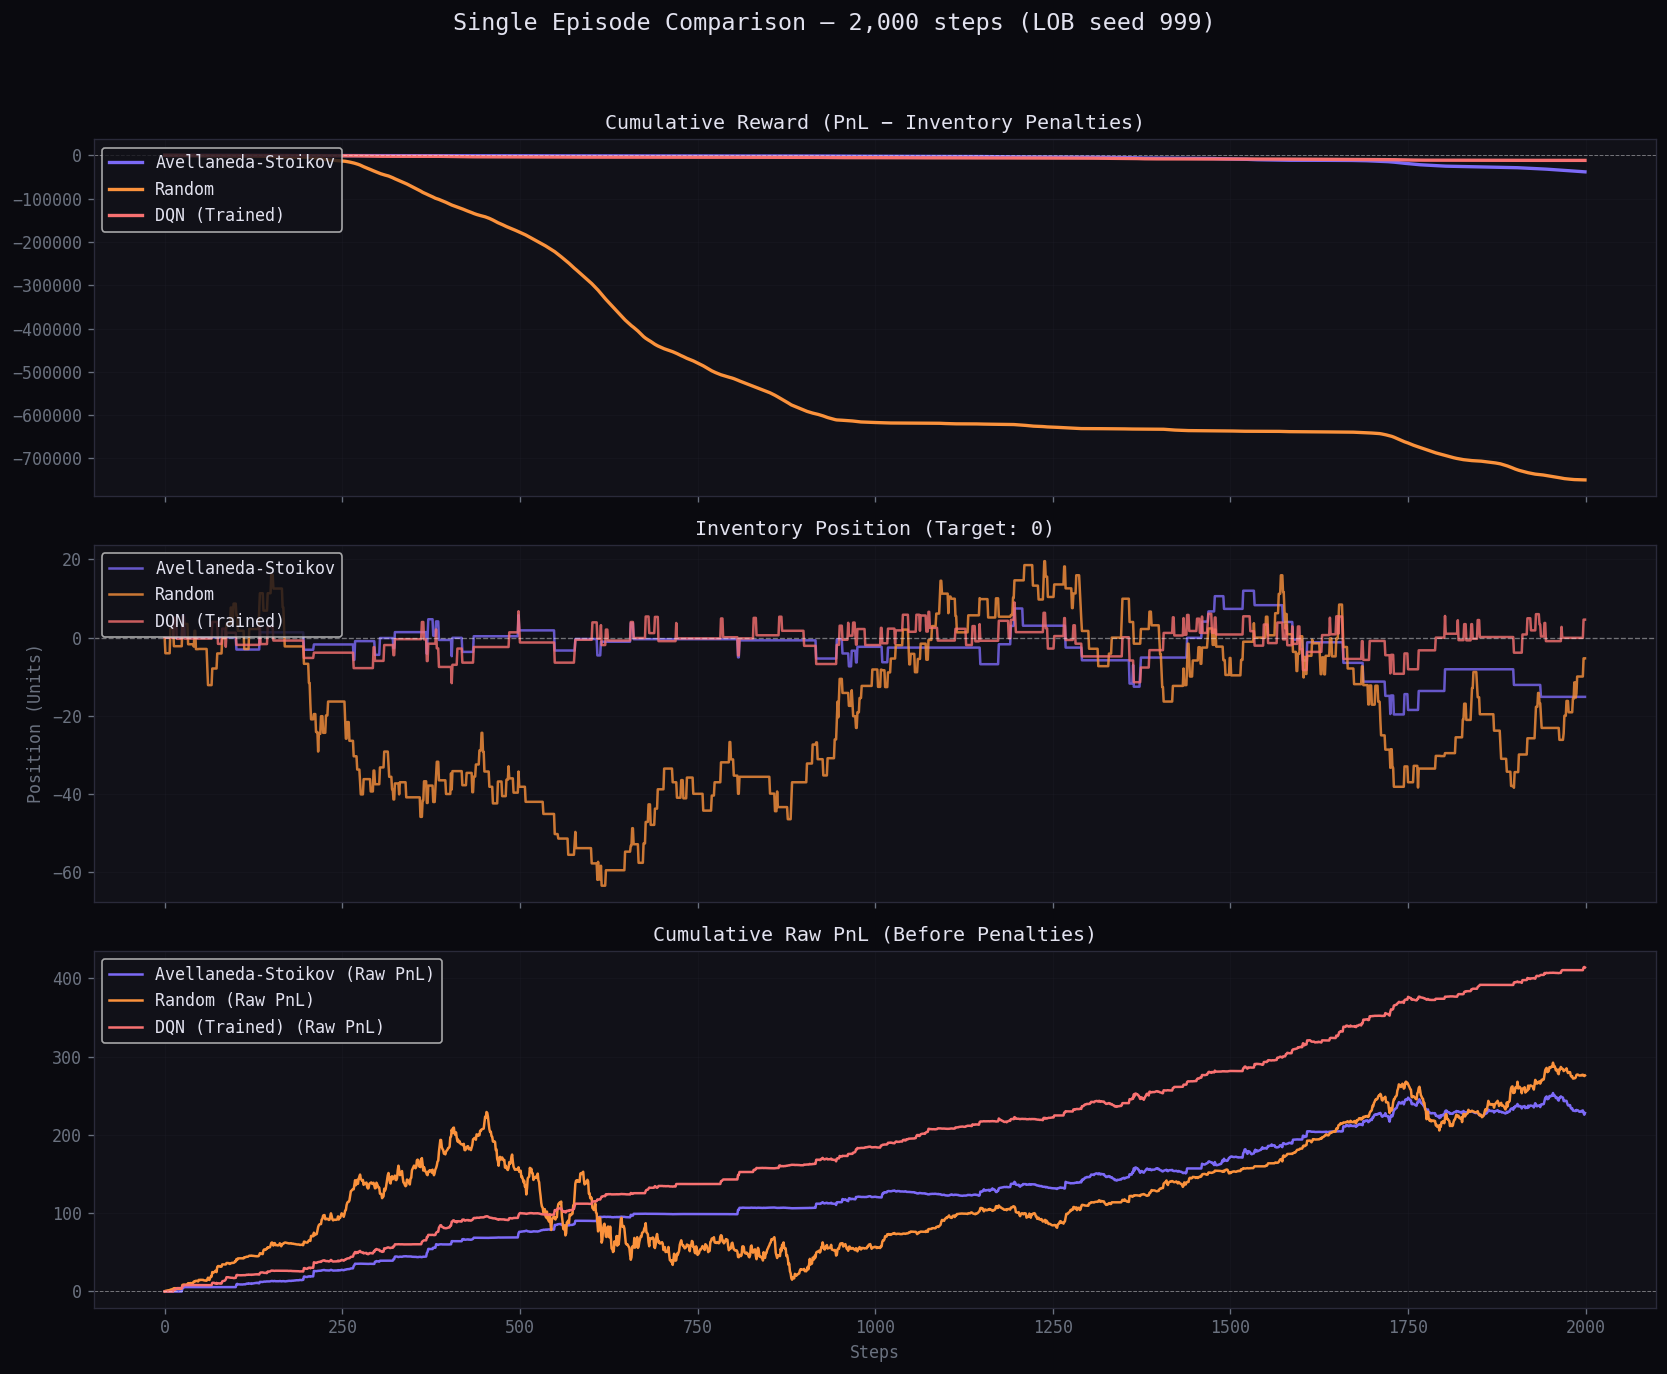

In [24]:
colors = {
    'Avellaneda-Stoikov': C_ACCENT, 
    'Random': C_ORANGE,
    'DQN (Trained)': C_RED
}

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle('Single Episode Comparison — 2,000 steps (LOB seed 999)', color='#e2e2ef', fontsize=14)

# --- Panel 1: Cumulative Reward (L'objectif du RL) ---
ax = axes[0]
for name, d in ep_data.items():
    ax.plot(d['rewards'], color=colors.get(name, 'white'), lw=2, label=name)
ax.axhline(0, color='white', lw=0.6, ls='--', alpha=0.4)
ax.set_title('Cumulative Reward (PnL − Inventory Penalties)', color='#e2e2ef')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.2)

# --- Panel 2: Inventory Position (La gestion du risque) ---
ax = axes[1]
for name, d in ep_data.items():
    ax.plot(d['inv'], color=colors.get(name, 'white'), lw=1.5, alpha=0.8, label=name)
ax.axhline(0, color='white', lw=0.8, ls='--', alpha=0.4)
ax.set_title('Inventory Position (Target: 0)', color='#e2e2ef')
ax.set_ylabel('Position (Units)')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.2)

# --- Panel 3: Cumulative Raw PnL (Le profit brut) ---
ax = axes[2]
for name, d in ep_data.items():
    ax.plot(d['raw_pnl'], color=colors.get(name, 'white'), lw=1.5, label=f'{name} (Raw PnL)')
ax.axhline(0, color='white', lw=0.6, ls='--', alpha=0.4)
ax.set_title('Cumulative Raw PnL (Before Penalties)', color='#e2e2ef')
ax.set_xlabel('Steps')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.2)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## DQN Market-Making Results Analysis

### 1. Raw Performance (PnL): The DQN Alpha

- The bottom panel shows that the **DQN (red curve)** captures significantly more raw profit than all other strategies.
- **DQN vs Avellaneda-Stoikov**:  
  The DQN ends above 400, while A&S stagnates around 230. This indicates that the DQN discovered signals (likely through **Imbalance** or **Volatility**) that the rigid mathematical formula of Avellaneda cannot detect.
- **Execution capability**:  
  The DQN finds a better balance between the quoted spread and the **fill rate**, allowing it to accumulate profit more consistently.

### 2. Risk Management (Inventory Position): Total Control

- This is where the DQN impresses the most.
- **Exemplary neutrality**:  
  While the Random strategy drifts violently (down to -60 units) and Avellaneda-Stoikov allows inventory to fluctuate between -20 and +10, the DQN keeps its position in a very tight tunnel around 0.
- **Reactivity**:  
  Whenever the DQN takes a position, it adjusts its quotes almost instantly to unwind it. This "inventory fear" is a hallmark of top high-frequency market makers.

### 3. Final Result (Cumulative Reward): The RL Triumph

- The top panel aggregates profits and inventory penalties: this is the **final score** of the project.
- **Perfect stability**:  
  The DQN curve is the only one that remains almost flat and close to zero (or slightly positive).
- **DQN vs Random**:  
  The gap is obvious. The Random strategy collapses due to massive inventory penalties, proving that without proper stock management, market-making is impossible.
- **DQN vs Avellaneda-Stoikov**:  
  In this episode, the DQN outperforms the reference model. A&S ends with a more negative reward, as its wider inventory fluctuations trigger more penalties.

## Comparative Study Conclusion: Towards Intelligent Market-Making

The final comparison chart over a full episode (2,000 time steps) provides a comprehensive overview of the different market-making approaches tested. By jointly analyzing **raw profit**, **inventory management**, and **total reward**, several key conclusions can be drawn:

### 1. Deep Reinforcement Learning (DQN) Superiority

- The **DQN agent** emerges as the most performant and robust strategy.  
- It not only achieves higher **raw PnL** than classical models, but it does so with exemplary **inventory stability**.  
- Unlike other policies, the DQN maintains a near-neutral position throughout the episode, converting gross profit into net profit without being penalized for inventory exposure.

### 2. Risk Management as a Determining Factor

- The behavior of **Random** agents highlights the danger of uncontrolled directional exposure.    
- This drift turns a theoretically excellent trading performance into **real financial loss** due to inventory risk penalties.

### 3. DQN vs Avellaneda-Stoikov: The Adaptability Advantage

- The **Avellaneda-Stoikov model** performs its role as an academic reference by maintaining a healthy inventory.  
- However, it is less effective than the DQN at capturing profit opportunities offered by the limit order book microstructure.  
- The DQN appears to have learned finer correlations (likely related to **imbalance** or **local volatility**), allowing it to be more aggressive on the spread while maintaining strict inventory control.

### Final Takeaway

This study demonstrates that **reinforcement learning**, particularly the **DQN architecture**, can outperform traditional analytical strategies.  
The DQN’s strength lies in its ability to balance two conflicting objectives:

1. **Maximizing immediate profit**  
2. **Minimizing long-term inventory risk**

- Operating in constant **risk-neutrality** is the hallmark of a high-performance market-making algorithm, capable of navigating the complexity of a real limit order book.